# VTuber LiveChat Engagement Analytics Using Apache Spark

## Descriptive Analytics of 2021 VTuber Live-Chat Activity

In [1]:
from pyspark.sql.functions import (
    col, count, avg, max, when, desc, lit,
    approx_count_distinct,
    broadcast,
    sum as spark_sum,
    collect_set,
    size,
    array_distinct,
    flatten,
    collect_list
)

from pyspark.sql import DataFrame
from pyspark.sql.window import Window
from pyspark.sql.functions import rank
from pyspark.sql import Row

import plotly.express as px
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("VTuber_Analytics")
    .master("local[*]") 
    .config("spark.driver.memory", "10g")
    .config(
        "spark.driver.extraJavaOptions",
        "-XX:+UseG1GC -XX:InitiatingHeapOccupancyPercent=35"
    )
    # Keep chunks small for memory safety
    .config("spark.sql.files.maxPartitionBytes", "67108864")  
    # Arrow makes the Spark -> Pandas transfer 10x to 100x faster.
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.sql.shuffle.partitions", "1000")
    # Give the Driver a bit more breathing room when collecting final results for plotting.
    .config("spark.driver.maxResultSize", "2g")
    .getOrCreate()
)

# I. Executive Summary

VTuber livestreams are not only about how many subscribers a channel have. In many cases, the real audience engagement can be seen more clearly through live-chat activity. Viewers who sends messages during streams are actively participating, reacting, and building the community around the VTuber.

The **VTuber LiveChat Engagement Analytics** project analyzes VTuber live-chat activity from 2021 using _**Apache Spark**_. The main goal is to understand which `channels`, `streams`, `agencies`, and audience groups shows the strongest live engagement. The analysis uses _raw event-level chat records_, where each row represents one chat message sent during a livestream.

The dataset includes important fields such as `timestamp`, `authorChannelId`, `videoId`, `channelId`, and `bodyLength`. The `isMember` column was not used because this study focus on general audience behavior instead of comparing paid members and non-members.

Based on the results, **Hololive** and **Nijisanji** generated the highest chat activity among the affiliations. Hololive also had the largest number of unique chatters, which suggest that its engagement is not only caused by repeated messages from a small group of users. Individual VTubers such as **`Usada Pekora`**, **`Sakura Miko`**, **`Gawr Gura`**, and **`Takanashi Kiara`** also showed very strong chat activity.

Overall, the study shows that live-chat records can be useful for understanding audience engagement beyond subscriber count. These insights may help agencies, advertisers, and sponsors identify creators with strong live audience interaction.

# II. Introduction

VTubers have become a major part of online livestreaming culture. Their communities are usually very active during livestreams, especially in the live-chat section where viewers react, comment, and communicate with the streamer and other fans.

Subscriber count can show how many people follow a channel, but it does not always show how active the audience really are. Some large channels may have many subscribers but lower chat activity, while some smaller channels may have viewers who are more active during streams.

Because of this, live-chat data is useful for measuring real-time audience engagement. In this project, Apache Spark is used to process and analyze a large VTuber live-chat dataset from 2021. The analysis focuses on chat volume, active users, stream activity, message length, agency performance, and audience behavior.

## Problem Statement

**How can large-scale VTuber live-chat records be used to measure and compare audience engagement across channels, streams, agencies, and time periods in 2021?**

# III. Motivation and Business Value

The motivation for this study is that _subscriber count alone is not enough to measure audience engagement_. 

A VTuber may have many subscribers, but this does not always mean that the viewers are active during livestreams. On the other hand, a channel with fewer subscribers may still have a very active and loyal live-chat community. Live-chat activity gives a more direct view of how viewers interact during streams. It can show which channels receive the most audience response, which agencies have stronger communities, and when chat activity is highest.

This is useful for business decisions because advertisers and sponsors usually want to work with creators who have active audiences. A sponsor may benefit more from a VTuber whose viewers actively participate in chat than from a channel that only has a high subscriber count but low live interaction.

The results of this study can help identify VTubers and agencies with strong live engagement. It can also support **sponsorship planning**, **campaign targeting**, and **audience research**.

# IV. Methodology

## Data Source

The dataset used in this project is the VTuber LiveChat dataset from Kaggle. The dataset contains raw live-chat records from VTuber livestreams. Each row represent one chat message sent by a viewer during a stream.

The main columns used in this study are:

| Column | Description |
|---|---|
| timestamp | The time when the chat message was sent |
| authorChannelId | The unique identifier of the chatter or viewer |
| videoId | The stream or video where the message appeared |
| channelId | The VTuber channel that received the chat message |
| bodyLength | The number of characters in the chat message |

The channel metadata file was also used to add extra information about each VTuber channel, such as English name and affiliation.

The `isMember` column was not included in the analysis because the study is focused on general audience behavior, not subscribers alone. This makes the project more simple and keeps the analysis aligned with the original proposal.

## Methodology Pipeline

The methodology followed these main steps:


        Raw VTuber chat files  
                    ↓  
        Read data using Apache Spark  
                    ↓  
        Inspect schema and identify usable columns  
                    ↓  
        Remove unnecessary columns and problematic files  
                    ↓  
        Check missing values and filter invalid records  
                    ↓  
        Join chat records with channel metadata  
                    ↓  
        Perform Spark SQL and DataFrame analytics  
                    ↓  
        Create visualizations and interpret results  
                    ↓  
        Summarize findings, limitations, and recommendations

This pipeline was designed to measure VTuber audience engagement from different perspectives, including channel-level activity, agency-level activity, time-based trends, message length, active users, and chat velocity.

In [3]:
CHATS_SOURCE = "./unified_chats_2021/"
CHANNELS_SOURCE = "./channels_2021.csv"

chats = spark.read.parquet(CHATS_SOURCE)
channels = spark.read.csv(
    CHANNELS_SOURCE,
    header=True,
    inferSchema=True,
)

chats.createOrReplaceTempView("chats")
channels.createOrReplaceTempView("channels")

chats.printSchema()
channels.printSchema()


root
 |-- timestamp: timestamp (nullable = true)
 |-- authorChannelId: string (nullable = true)
 |-- videoId: string (nullable = true)
 |-- channelId: string (nullable = true)
 |-- bodyLength: long (nullable = true)

root
 |-- _c0: integer (nullable = true)
 |-- channelId: string (nullable = true)
 |-- name: string (nullable = true)
 |-- englishName: string (nullable = true)
 |-- affiliation: string (nullable = true)
 |-- videoCount: integer (nullable = true)



In [4]:
channels.show(5)

+---+--------------------+----------------------------+--------------------+-----------+----------+
|_c0|           channelId|                        name|         englishName|affiliation|videoCount|
+---+--------------------+----------------------------+--------------------+-----------+----------+
|  0|UCJFZiqLMntJufDCH...|   hololive ホロライブ - ...|Hololive VTuber G...|   Hololive|       509|
|  1|UCfrWoRGlawPQDQxx...|          hololive Indonesia|  Hololive Indonesia|   Hololive|        69|
|  2|UCotXwY6s8pWmuWd_...|            hololive English|    Hololive English|   Hololive|        34|
|  3|UCWsfcksUUpoEvhia...|  holostars ホロスターズ ...|  Holostars Official|   Hololive|       150|
|  4|UCp6993wxpyDPHUpa...|SoraCh. ときのそらチャンネル|         Tokino Sora|   Hololive|       667|
+---+--------------------+----------------------------+--------------------+-----------+----------+
only showing top 5 rows


In [5]:
from pyspark.sql import functions as F

chats.select(
    F.countDistinct("authorChannelId").alias("unique_chatters"),
    F.countDistinct("videoId").alias("unique_streams"),
    F.countDistinct("channelId").alias("unique_channels")
).show()

chats.select(
    F.min("timestamp").alias("start_date"),
    F.max("timestamp").alias("end_date")
).show()

+---------------+--------------+---------------+
|unique_chatters|unique_streams|unique_channels|
+---------------+--------------+---------------+
|        3897984|         84346|            896|
+---------------+--------------+---------------+

+--------------------+--------------------+
|          start_date|            end_date|
+--------------------+--------------------+
|2021-01-15 13:15:...|2021-12-01 07:59:...|
+--------------------+--------------------+



In [6]:
from pyspark.sql.functions import col, sum as spark_sum

null_summary = chats.select([
    spark_sum(col(c).isNull().cast("int")).alias(c)
    for c in chats.columns
])

null_summary.show()

+---------+---------------+-------+---------+----------+
|timestamp|authorChannelId|videoId|channelId|bodyLength|
+---------+---------------+-------+---------+----------+
|        0|              0|      0|        0|         0|
+---------+---------------+-------+---------+----------+



# V. Results and Discussion

## Research Question 1: Which VTuber channels receive the most chats?

This analysis identifies the VTuber channels with the highest total number of chat messages in 2021. The number of chat messages was used as a basic measure of live audience activity.

### Insight

The results show that **Usada Pekora** received the highest total chat volume, with more than 31 million messages. This suggest that her livestreams had very strong audience participation during 2021. Other VTubers such as **Sakura Miko**, **Gawr Gura**, **Takanashi Kiara**, and **Oozora Subaru** also ranked highly. These channels appears to have very active live-chat communities.

From a business point of view, these VTubers may be _good candidates for sponsorship or promotional campaigns_ because their audiences are not only watching but also _actively interacting during streams_.

In [7]:
def most_channel():
    """
    Which VTuber channels receive the most chats?
    """

    query = """
    SELECT channels.englishName as `English Name`, COUNT(*) as `Total Chats`
    FROM chats
    JOIN channels
    ON chats.channelId = channels.channelId
    GROUP BY channels.englishName
    ORDER BY `Total Chats` DESC
    LIMIT 20;
    """
    
    return spark.sql(query)

In [8]:
q1 = most_channel()
q1.show()

+----------------+-----------+
|    English Name|Total Chats|
+----------------+-----------+
|    Usada Pekora|   31144439|
|     Sakura Miko|   18542086|
|       Gawr Gura|   14632354|
| Takanashi Kiara|   13825699|
|   Oozora Subaru|   13272619|
|   Yukihana Lamy|   12801025|
|    Uruha Rushia|   12543306|
|Tsunomaki Watame|   12109778|
|  Houshou Marine|   11744882|
|   Watson Amelia|   11272410|
|          Kuzuha|   11165917|
|  Inugami Korone|   11019240|
|    Amane Kanata|    9697269|
|           Kanae|    9187275|
| Ninomae Ina’nis|    8529349|
|Shirakami Fubuki|    8512457|
|      Kiryu Coco|    8232139|
|   Mori Calliope|    8223660|
|     Fuwa Minato|    8119214|
|  Nekomata Okayu|    8070036|
+----------------+-----------+



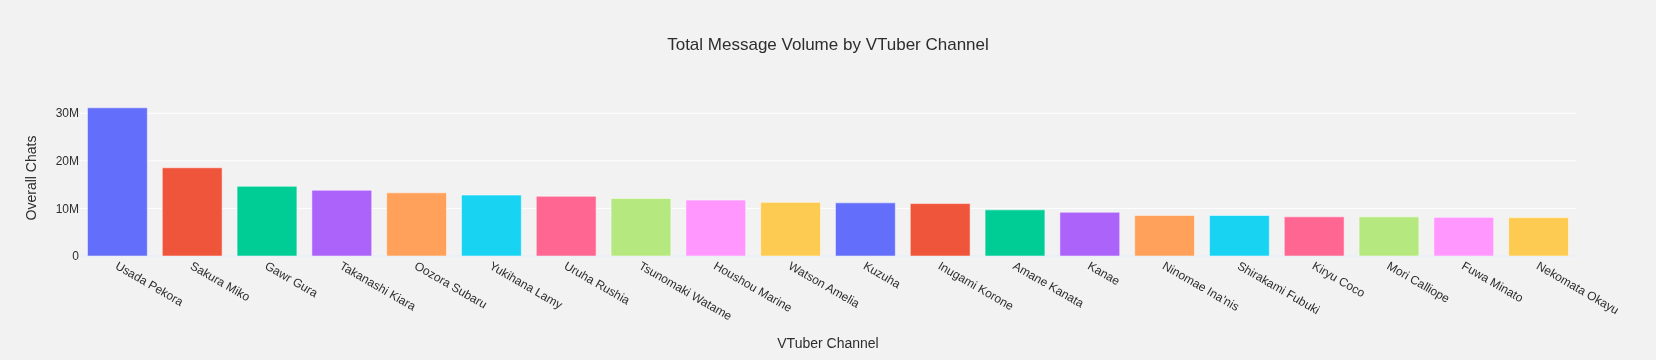

In [9]:
top_channels_df = q1.toPandas()

fig1 = px.bar(
    top_channels_df,
    x="English Name",
    y="Total Chats",
    title="Total Message Volume by VTuber Channel",
    labels={"English Name": "VTuber Channel", "Total Chats": "Overall Chats"},
    color="English Name",
    template="plotly_white",
)

fig1.update_layout(
    plot_bgcolor="#F2F2F2",
    paper_bgcolor="#F2F2F2",
    font=dict(color="#2D2D2D"),
    title_x=0.5,
    showlegend=False,
)

fig1.update_xaxes(showgrid=False)
fig1.update_yaxes(gridcolor="white")

fig1.show()

In [10]:
def mo_stream_chats():
    """
    How many stream chats done per month of the year 2021?
    """

    query = """
    SELECT 
        DATE_FORMAT(timestamp, 'yyyy-MM') AS `year-month`,
        COUNT(*) AS total_chats
    FROM chats
    GROUP BY DATE_FORMAT(timestamp, 'yyyy-MM')
    ORDER BY `year-month`;
    """
    return spark.sql(query)

In [11]:
q2 = mo_stream_chats()
q2.show()

+----------+-----------+
|year-month|total_chats|
+----------+-----------+
|   2021-01|    1998144|
|   2021-02|   30707138|
|   2021-03|   67126793|
|   2021-04|   63446229|
|   2021-05|   75898905|
|   2021-06|   75388311|
|   2021-07|   80829747|
|   2021-08|   99281411|
|   2021-09|   87760727|
|   2021-10|   83370517|
|   2021-11|   81942259|
|   2021-12|     591577|
+----------+-----------+



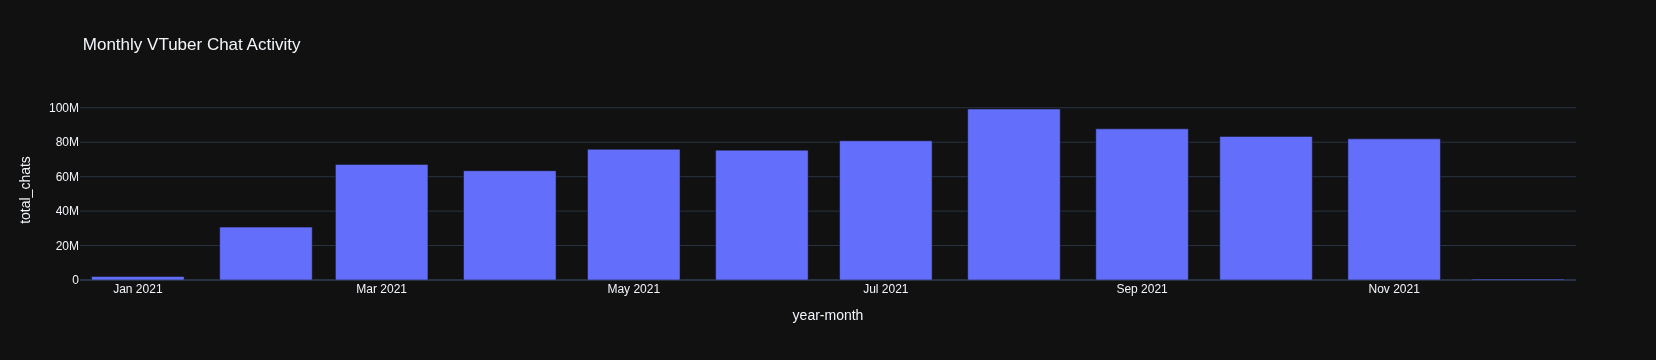

In [12]:
# Reverse the dataframe so the highest value is at the top of the chart
fig2 = px.bar(
    q2.toPandas(), 
    x='year-month', 
    y='total_chats', 
    orientation='v',
    title='Monthly VTuber Chat Activity',
    template='plotly_dark'
)
fig2.show()

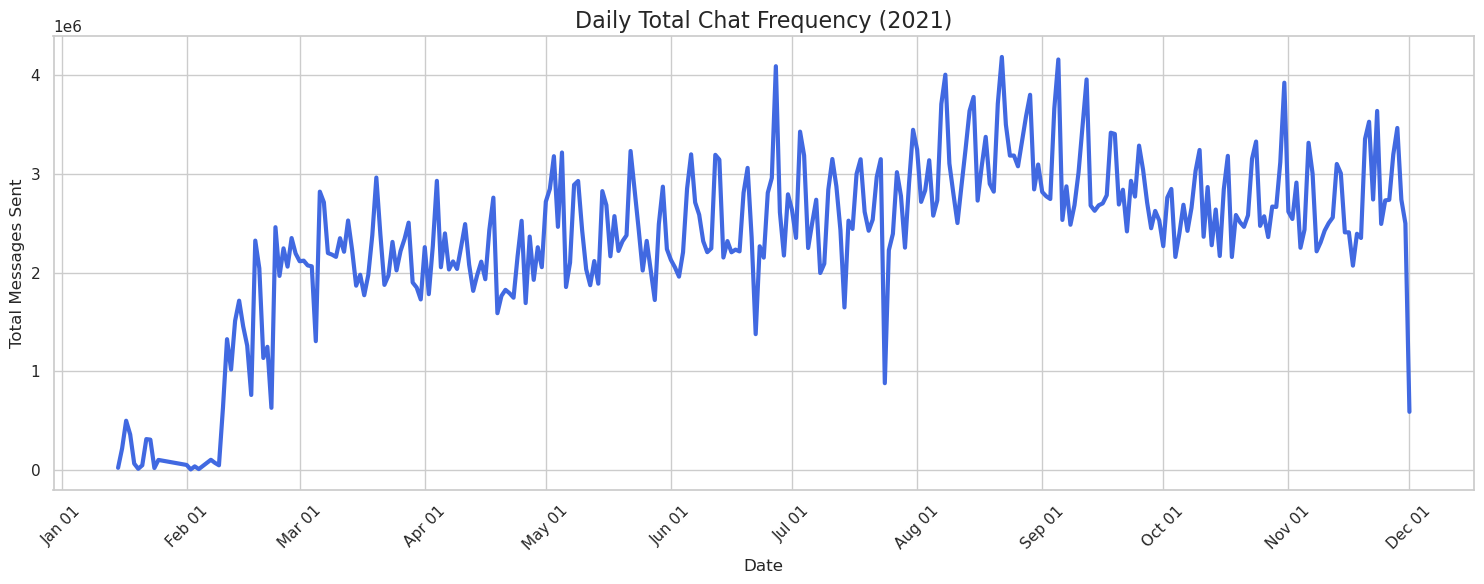

In [13]:
def get_daily_chat_counts():
    """Return daily chat totals across all VTuber channels."""
    query = """
    SELECT
        DATE(timestamp) AS chat_date,
        COUNT(*) AS daily_chats
    FROM chats
    GROUP BY DATE(timestamp)
    ORDER BY chat_date;
    """
    return spark.sql(query)


q3_df = get_daily_chat_counts().toPandas()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))

sns.lineplot(
    data=q3_df,
    x="chat_date",
    y="daily_chats",
    color="royalblue",
    linewidth=3,
)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())

plt.title("Daily Total Chat Frequency (2021)", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Messages Sent", fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


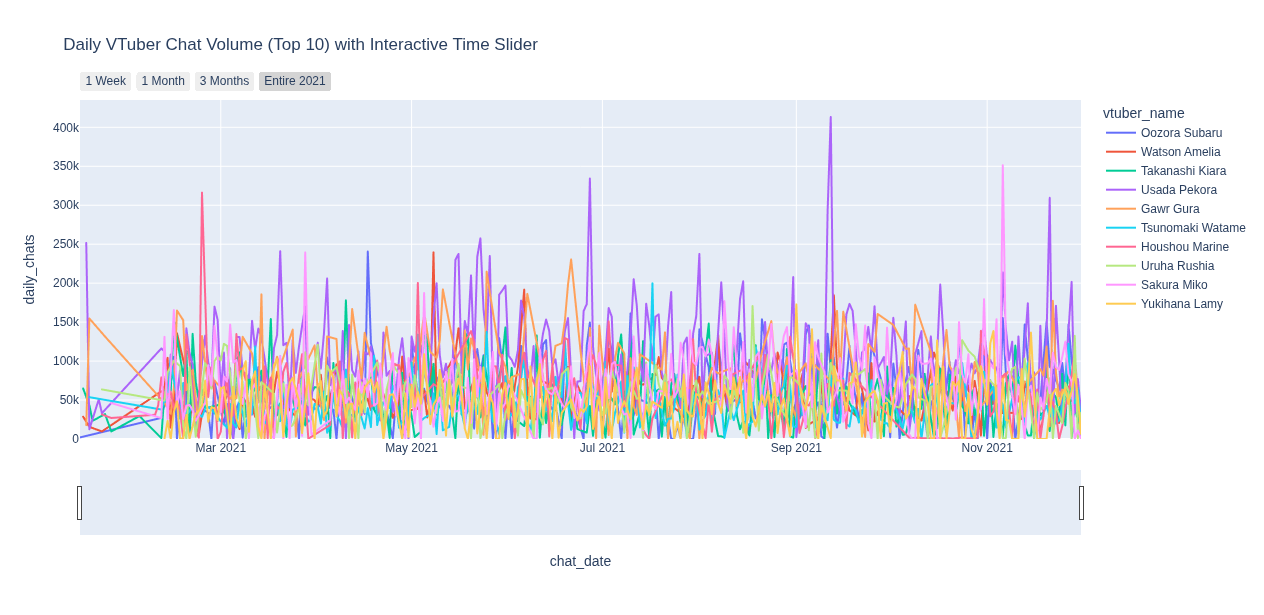

In [14]:
# 1. Spark does the heavy lifting: Find Top 10, Join, and Group

def vtuber_daily():
    """
    Observe the daily chat activity of
    some of the popular Vtubers
    """
    query = """
    -- Step A: Find the Top 10 Channels by total chat volume
    WITH Top10Channels AS (
        SELECT channelId, COUNT(*) as total_chats
        FROM chats
        GROUP BY channelId
        ORDER BY total_chats DESC
        LIMIT 10
    )
    -- Step B: Join that top 10 list with the main data and channels table
    SELECT DATE(c.timestamp) AS chat_date,
           ch.englishName AS vtuber_name,
           COUNT(*) AS daily_chats
    FROM chats c
    JOIN channels ch ON c.channelId = ch.channelId
    JOIN Top10Channels t ON c.channelId = t.channelId
    GROUP BY DATE(c.timestamp), ch.englishName
    ORDER BY chat_date;
    """
    return spark.sql(query)


q3_modified_df = vtuber_daily().toPandas()


fig = px.line(
    q3_modified_df,
    x='chat_date',
    y='daily_chats',
    color='vtuber_name',
    title='Daily VTuber Chat Volume (Top 10) with Interactive Time Slider',
    width=1500,
    height=600
)


fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=7, label="1 Week", step="day", stepmode="backward"),
            dict(count=1, label="1 Month", step="month", stepmode="backward"),
            dict(count=3, label="3 Months", step="month", stepmode="backward"),
            dict(step="all", label="Entire 2021")
        ])
    )
)


fig.update_yaxes(rangemode="tozero")
display(fig)


In [15]:
vtuber_daily().show(50)

+----------+----------------+-----------+
| chat_date|     vtuber_name|daily_chats|
+----------+----------------+-----------+
|2021-01-15|   Oozora Subaru|       2015|
|2021-01-16|   Watson Amelia|      28653|
|2021-01-16| Takanashi Kiara|      64832|
|2021-01-17|    Usada Pekora|     251729|
|2021-01-17|       Gawr Gura|      17713|
|2021-01-18|   Watson Amelia|      15517|
|2021-01-18|Tsunomaki Watame|      53645|
|2021-01-18|       Gawr Gura|     154646|
|2021-01-18|    Usada Pekora|      12474|
|2021-01-18| Takanashi Kiara|      43202|
|2021-01-19| Takanashi Kiara|      23299|
|2021-01-21|    Usada Pekora|      50936|
|2021-01-22|  Houshou Marine|      31455|
|2021-01-22|   Watson Amelia|       9709|
|2021-01-22|    Usada Pekora|      33095|
|2021-01-22|    Uruha Rushia|      63625|
|2021-01-23| Takanashi Kiara|      31974|
|2021-01-23|       Gawr Gura|     131495|
|2021-01-25| Takanashi Kiara|       9697|
|2021-01-25|  Houshou Marine|      26947|
|2021-01-25|     Sakura Miko|     

-----
Are longer chats more common in some streams or channels?

In [16]:
def long_chat():
    """
    Are longer chats more common in some streams or channels?
    """
    query = """
    SELECT ch.englishName AS `English Name`,
        AVG(c.bodyLength) AS avg_chat_length,
        COUNT(*) AS total_chats
    FROM chats c
    JOIN channels ch
    ON c.channelId = ch.channelId
    GROUP BY ch.englishName
    HAVING total_chats > 5000  -- Filters out low-chat anomalies
    ORDER BY avg_chat_length DESC;
    """
    return spark.sql(query)

In [17]:
# 1. Execute the query and convert to Pandas
df_pd = long_chat().toPandas()

# 2. Generate Scatter Plot
fig1 = px.scatter(
    df_pd, 
    x='total_chats', 
    y='avg_chat_length', 
    hover_name='English Name',          # Shows the VTuber name when hovering over a dot
    size='total_chats',                 # Optional: Makes dots bigger for higher chat volumes
    title='Average Chat Length vs. Total Chat Volume per VTuber',
    labels={
        'total_chats': 'Total Chat Volume', 
        'avg_chat_length': 'Average Chat Length (characters)'
    },
    template='plotly_dark',              # Optional: Gives it a sleek dark theme
    width=1600,
    height=900
)

# 3. Customize the background to light gray
fig1.update_layout(
    plot_bgcolor='#F2F2F2',   # Light gray for the plotting area
    paper_bgcolor='#F2F2F2',  # Light gray for the surrounding paper area
    font=dict(color='#2D2D2D'), # Dark gray text for better readability on light bg
    title_x=0.5               # Centers the title for better UX
)

# 4. Refine the grid lines for a cleaner look
fig1.update_xaxes(showgrid=False)
fig1.update_yaxes(gridcolor='white') # White grid lines pop slightly against light gray

# 5. Refine marker transparency and border
fig1.update_traces(
    marker=dict(
        opacity=0.7, 
        line=dict(width=1, color='#FFFFFF') # Added a white border to make overlapping dots distinct
    )
) 

fig1.show()

In [18]:
long_chat().show(20, truncate=False)

+---------------+------------------+-----------+
|English Name   |avg_chat_length   |total_chats|
+---------------+------------------+-----------+
|Walfie         |34.25545092586741 |15823      |
|Europa         |30.256508875739645|6760       |
|Ushio Ebi      |27.13420306398048 |222521     |
|Pipkin Pippa   |26.941926459667343|335299     |
|Orla Gan Ceann |26.629163400680884|85477      |
|Kaga Oren      |25.966904345486345|22299      |
|Tsurugi Nen    |25.54158964879852 |7033       |
|Cecile         |25.038280616382806|24660      |
|Yazaki Kallin  |25.01006081654584 |128419     |
|FruFru VTubers |24.907278733340927|17558      |
|Jaret Fajrianto|24.826221939181657|12562      |
|Shee Icho      |24.79529848937717 |61895      |
|Fujikura Uruka |24.738833804454725|161671     |
|Tetsuya Kazune |24.548014359434596|26742      |
|Mana Renewal   |24.499610776369554|360975     |
|Kyria          |24.15782109345106 |175097     |
|Rinkou Ashelia |24.148406902441177|135836     |
|Kitsui Akira   |23.

-----

### Basic Aggregation: Total Message Volume by Affiliation

Business Objective: Get a __macro-level__ view of which VTuber agencies drive the highest total volume of chat interactions across all their talents.

Concepts: `INNER JOIN`, `COUNT`, `GROUP BY`, `ORDER BY`

In [19]:
def get_affiliation_message_counts():
    """Return total chat message counts by VTuber affiliation."""
    query = """
    SELECT
        ch.affiliation,
        COUNT(1) AS total_messages
    FROM chats c
    JOIN channels ch
        ON c.channelId = ch.channelId
    WHERE ch.affiliation IS NOT NULL
    GROUP BY ch.affiliation
    ORDER BY total_messages DESC
    LIMIT 20;
    """
    return spark.sql(query)


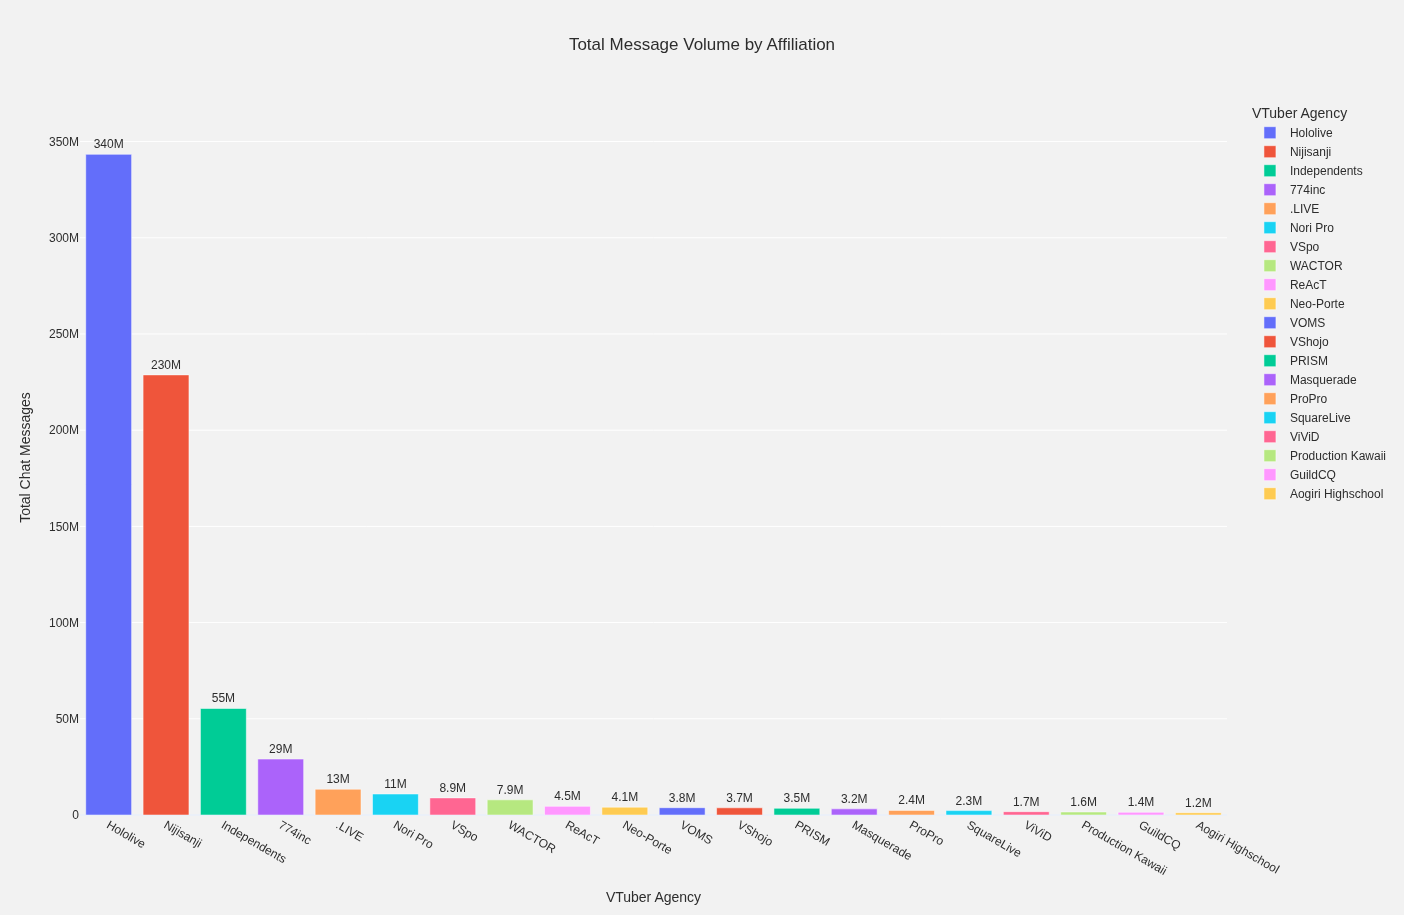

In [20]:
affiliation_messages_df = get_affiliation_message_counts().toPandas()

fig1 = px.bar(
    affiliation_messages_df,
    x="affiliation",
    y="total_messages",
    title="Total Message Volume by Affiliation",
    labels={
        "affiliation": "VTuber Agency",
        "total_messages": "Total Chat Messages",
    },
    color="affiliation",
    template="plotly_white",
    width=1600,
    height=900,
)

fig1.update_layout(
    plot_bgcolor="#F2F2F2",
    paper_bgcolor="#F2F2F2",
    font=dict(color="#2D2D2D"),
    title_x=0.5,
)

fig1.update_xaxes(showgrid=False)
fig1.update_yaxes(gridcolor="white")
fig1.update_traces(
    texttemplate="%{y:.2s}",
    textposition="outside",
)

fig1.show()


In [21]:
x5().show()

+-----------------+--------------+
|      affiliation|total_messages|
+-----------------+--------------+
|         Hololive|     343361344|
|        Nijisanji|     228736400|
|     Independents|      55363350|
|           774inc|      29060655|
|            .LIVE|      13396002|
|         Nori Pro|      10915298|
|             VSpo|       8898313|
|           WACTOR|       7878021|
|            ReAcT|       4510546|
|        Neo-Porte|       4062434|
|             VOMS|       3787485|
|           VShojo|       3739429|
|            PRISM|       3482182|
|       Masquerade|       3187352|
|           ProPro|       2396761|
|       SquareLive|       2278501|
|            ViViD|       1731292|
|Production Kawaii|       1564174|
|          GuildCQ|       1423863|
|Aogiri Highschool|       1177198|
+-----------------+--------------+



-----

## Research Question 2: Which agencies drive the most engagement?

This analysis groups chat messages by VTuber affiliation or agency. The goal is to compare which agencies generated the highest overall chat activity.

### Insight

* **Hololive** generated the highest total number of messages, followed by Nijisanji. This shows that large VTuber agencies have very strong audience engagement and large active communities.

* **Hololive** also had the highest number of unique chatters, which means its engagement is not only from a few users sending many messages. Instead, many different viewers participated in the live chats.

* **Independent** VTubers also ranked high compared with smaller agencies. This is interesting because it shows that independent creators can still build active communities even without the support of a large agency.

### Basic Filtering: Top 10 Most Active VTubers in a Specific Agency

Business Objective: Drill down into a specific agency (e.g., **Nijisanji**) to identify their top performers based purely on standard text chat engagement.

Concepts: `WHERE` filtering with multiple conditions

In [22]:
def get_affiliation_channel_counts():
    """Return channel chat counts for selected VTuber affiliations."""
    query = """
    SELECT
        ch.englishName,
        ch.affiliation,
        COUNT(c.channelId) AS count
    FROM chats c
    JOIN channels ch
        ON c.channelId = ch.channelId
    WHERE ch.affiliation IN (
        'Nijisanji',
        'Hololive',
        '774inc',
        'Nori Pro',
        'Independents'
    )
    GROUP BY ch.englishName, ch.affiliation
    ORDER BY count DESC;
    """
    return spark.sql(query)


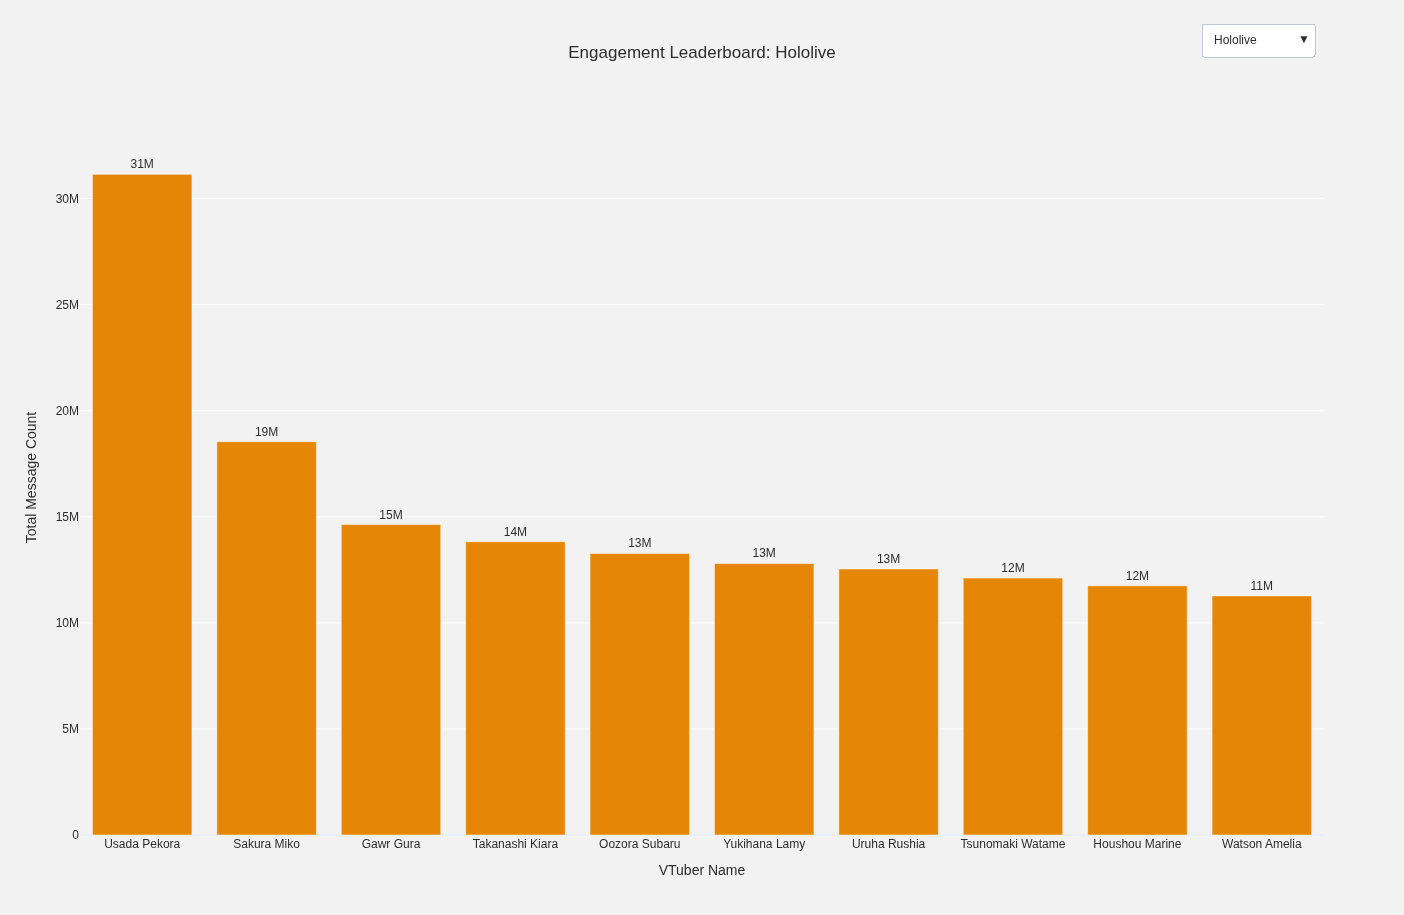

In [23]:
affiliation_channels_df = get_affiliation_channel_counts().toPandas()
affiliations = affiliation_channels_df["affiliation"].unique()
palette = px.colors.qualitative.Vivid

fig = go.Figure()

for index, affiliation in enumerate(affiliations):
    affiliation_df = affiliation_channels_df[
        affiliation_channels_df["affiliation"] == affiliation
    ].head(10)
    trace_color = palette[index % len(palette)]

    fig.add_trace(
        go.Bar(
            x=affiliation_df["englishName"],
            y=affiliation_df["count"],
            name=affiliation,
            marker_color=trace_color,
            text=affiliation_df["count"],
            texttemplate="%{y:.2s}",
            textposition="outside",
            visible=False,
        )
    )

if fig.data:
    fig.data[0].visible = True

buttons = []
for index, affiliation in enumerate(affiliations):
    visibility = [False] * len(affiliations)
    visibility[index] = True
    buttons.append(
        dict(
            label=affiliation,
            method="update",
            args=[
                {"visible": visibility},
                {"title": f"Engagement Leaderboard: {affiliation}"},
            ],
        )
    )

fig.update_layout(
    width=1600,
    height=900,
    template="plotly_white",
    plot_bgcolor="#F2F2F2",
    paper_bgcolor="#F2F2F2",
    font=dict(color="#2D2D2D"),
    updatemenus=[
        dict(
            active=0,
            buttons=buttons,
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=1.0,
            xanchor="right",
            y=1.15,
            yanchor="top",
            bgcolor="#FFFFFF",
            font=dict(color="#2D2D2D"),
        )
    ],
    title={
        "text": f"Engagement Leaderboard: {affiliations[0]}",
        "y": 0.95,
        "x": 0.5,
        "xanchor": "center",
        "yanchor": "top",
    },
    xaxis_title="VTuber Name",
    yaxis_title="Total Message Count",
    margin=dict(t=120),
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(gridcolor="white")
fig.show()


In [24]:
get_affiliation_channel_counts().show()

+----------------+-----------+--------+
|     englishName|affiliation|   count|
+----------------+-----------+--------+
|    Usada Pekora|   Hololive|31144439|
|     Sakura Miko|   Hololive|18542086|
|       Gawr Gura|   Hololive|14632354|
| Takanashi Kiara|   Hololive|13825699|
|   Oozora Subaru|   Hololive|13272619|
|   Yukihana Lamy|   Hololive|12801025|
|    Uruha Rushia|   Hololive|12543306|
|Tsunomaki Watame|   Hololive|12109778|
|  Houshou Marine|   Hololive|11744882|
|   Watson Amelia|   Hololive|11272410|
|          Kuzuha|  Nijisanji|11165917|
|  Inugami Korone|   Hololive|11019240|
|    Amane Kanata|   Hololive| 9697269|
|           Kanae|  Nijisanji| 9187275|
| Ninomae Ina’nis|   Hololive| 8529349|
|Shirakami Fubuki|   Hololive| 8512457|
|      Kiryu Coco|   Hololive| 8232139|
|   Mori Calliope|   Hololive| 8223660|
|     Fuwa Minato|  Nijisanji| 8119214|
|  Nekomata Okayu|   Hololive| 8070036|
+----------------+-----------+--------+
only showing top 20 rows


-----


## Research Question 3: How does chat frequency change over time?

This analysis groups chat messages by month to observe how VTuber live-chat activity changed throughout 2021.

### Insight

The monthly trend shows that chat activity increased strongly from February to August 2021. August had the highest total chat volume, which means it was the most active month in the dataset.

However, January and December had unusually low chat counts. These values should not immediately be interpreted as a real drop in audience engagement. It is possible that the data for these months are incomplete, corrupted, or partially excluded during preprocessing.

This is an important limitation of the dataset. Even though the trend still shows useful patterns, the low values in January and December should be explained carefully in the report.

### Date Truncation: Daily Chat Volume Comparison Among Major Agencies

Business Objective: Compare the daily engagement trends of the major agencies side-by-side to see who "won" specific days (e.g., during major 3D live events or agency-wide tournaments).

Concepts: `TO_DATE()`, Time-based grouping across multiple dimensions

In [25]:
def get_daily_affiliation_message_counts():
    """Return daily chat totals for selected VTuber affiliations."""
    query = """
    SELECT
        ch.affiliation,
        TO_DATE(c.timestamp) AS stream_date,
        COUNT(1) AS daily_messages
    FROM chats c
    JOIN channels ch
        ON c.channelId = ch.channelId
    WHERE ch.affiliation IN (
        'Nijisanji',
        'Hololive',
        '774inc',
        'Nori Pro',
        'Independents'
    )
    GROUP BY ch.affiliation, TO_DATE(c.timestamp)
    ORDER BY stream_date ASC, daily_messages DESC;
    """
    return spark.sql(query)

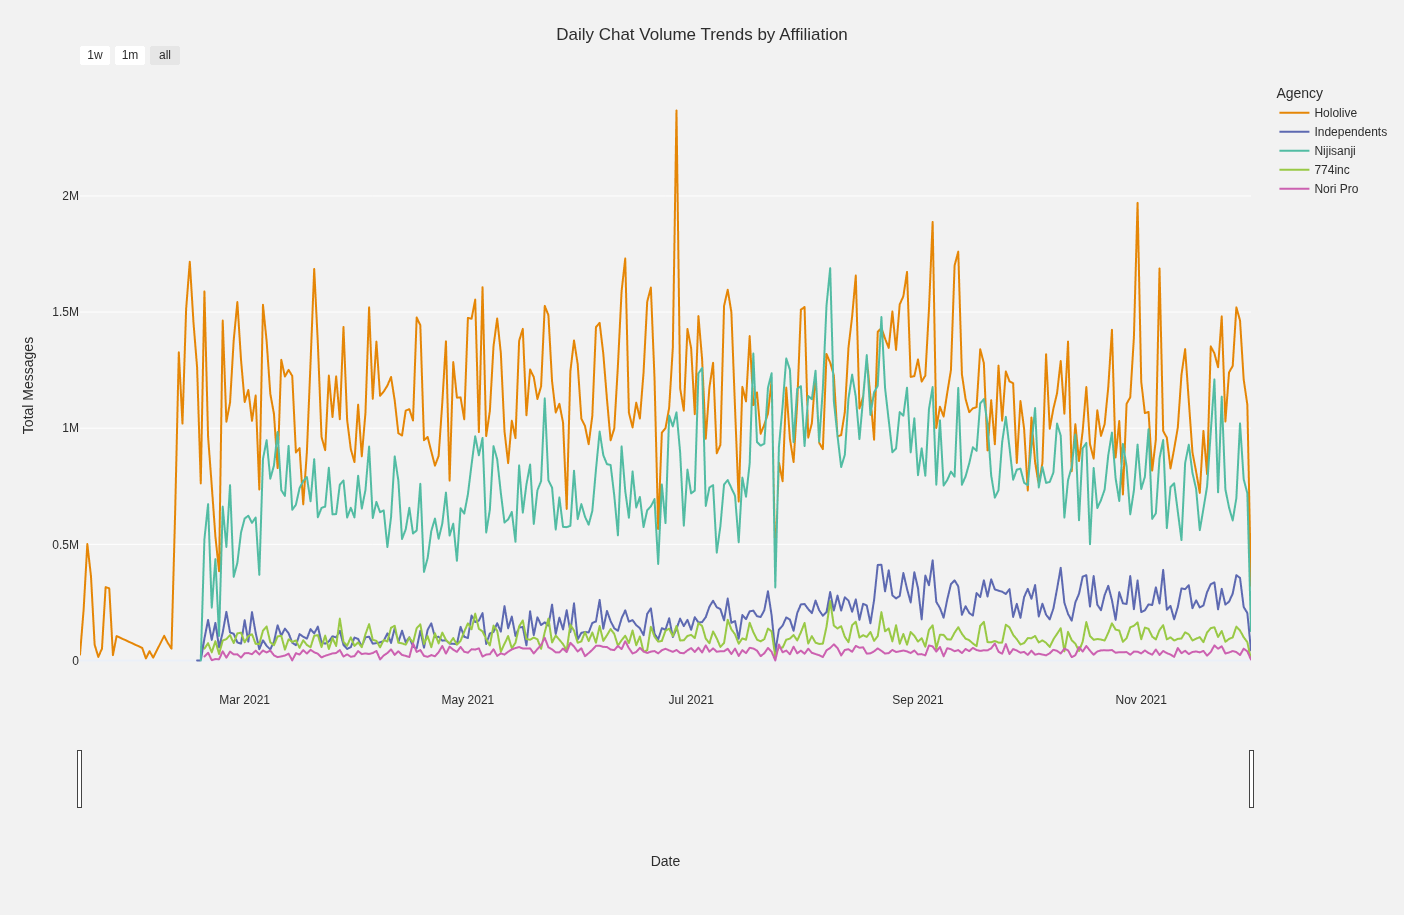

In [26]:
daily_affiliation_messages_df = get_daily_affiliation_message_counts().toPandas()

fig = px.line(
    daily_affiliation_messages_df,
    x="stream_date",
    y="daily_messages",
    color="affiliation",
    title="Daily Chat Volume Trends by Affiliation",
    labels={
        "stream_date": "Date",
        "daily_messages": "Total Messages",
        "affiliation": "Agency",
    },
    template="plotly_white",
    color_discrete_sequence=px.colors.qualitative.Vivid,
    width=1600,
    height=900,
)

fig.update_layout(
    plot_bgcolor="#F2F2F2",
    paper_bgcolor="#F2F2F2",
    font=dict(color="#2D2D2D"),
    title_x=0.5,
    hovermode="x unified",
    margin=dict(t=80, b=80),
)

fig.update_xaxes(
    showgrid=False,
    rangeslider_visible=True,
    rangeselector=dict(
        bgcolor="#FFFFFF",
        activecolor="#E6E6E6",
        buttons=list(
            [
                dict(count=7, label="1w", step="day", stepmode="backward"),
                dict(count=1, label="1m", step="month", stepmode="backward"),
                dict(step="all"),
            ]
        ),
    ),
)

fig.update_yaxes(gridcolor="white")
fig.show()


In [27]:
get_daily_affiliation_message_counts().show()

+-----------+-----------+--------------+
|affiliation|stream_date|daily_messages|
+-----------+-----------+--------------+
|   Hololive| 2021-01-15|         25083|
|   Hololive| 2021-01-16|        220849|
|   Hololive| 2021-01-17|        501428|
|   Hololive| 2021-01-18|        362902|
|   Hololive| 2021-01-19|         67864|
|   Hololive| 2021-01-20|         15177|
|   Hololive| 2021-01-21|         50936|
|   Hololive| 2021-01-22|        315740|
|   Hololive| 2021-01-23|        310307|
|   Hololive| 2021-01-24|         22888|
|   Hololive| 2021-01-25|        104970|
|   Hololive| 2021-02-01|         53981|
|   Hololive| 2021-02-02|          8859|
|   Hololive| 2021-02-03|         39834|
|   Hololive| 2021-02-04|         12087|
|   Hololive| 2021-02-07|        106372|
|   Hololive| 2021-02-08|         75385|
|   Hololive| 2021-02-09|         50776|
|   Hololive| 2021-02-10|        636932|
|   Hololive| 2021-02-11|       1326800|
+-----------+-----------+--------------+
only showing top

-----

### Common Table Expressions (CTE): Unique Audience Size per Affiliation

Business Objective: Message volume can be skewed by chat spammers. This query calculates the unique number of individual viewers chatting within each agency's ecosystem.

Concepts: `WITH (CTE), COUNT(DISTINCT ...)`

In [28]:
def get_affiliation_unique_chatter_counts():
    """Return unique chatter counts by VTuber affiliation."""
    query = """
    WITH AgencyAudience AS (
        SELECT
            ch.affiliation,
            c.authorChannelId
        FROM chats c
        JOIN channels ch
            ON c.channelId = ch.channelId
        WHERE ch.affiliation IS NOT NULL
        GROUP BY ch.affiliation, c.authorChannelId
    )
    SELECT
        affiliation,
        COUNT(DISTINCT authorChannelId) AS unique_chatters
    FROM AgencyAudience
    GROUP BY affiliation
    ORDER BY unique_chatters DESC;
    """
    return spark.sql(query)


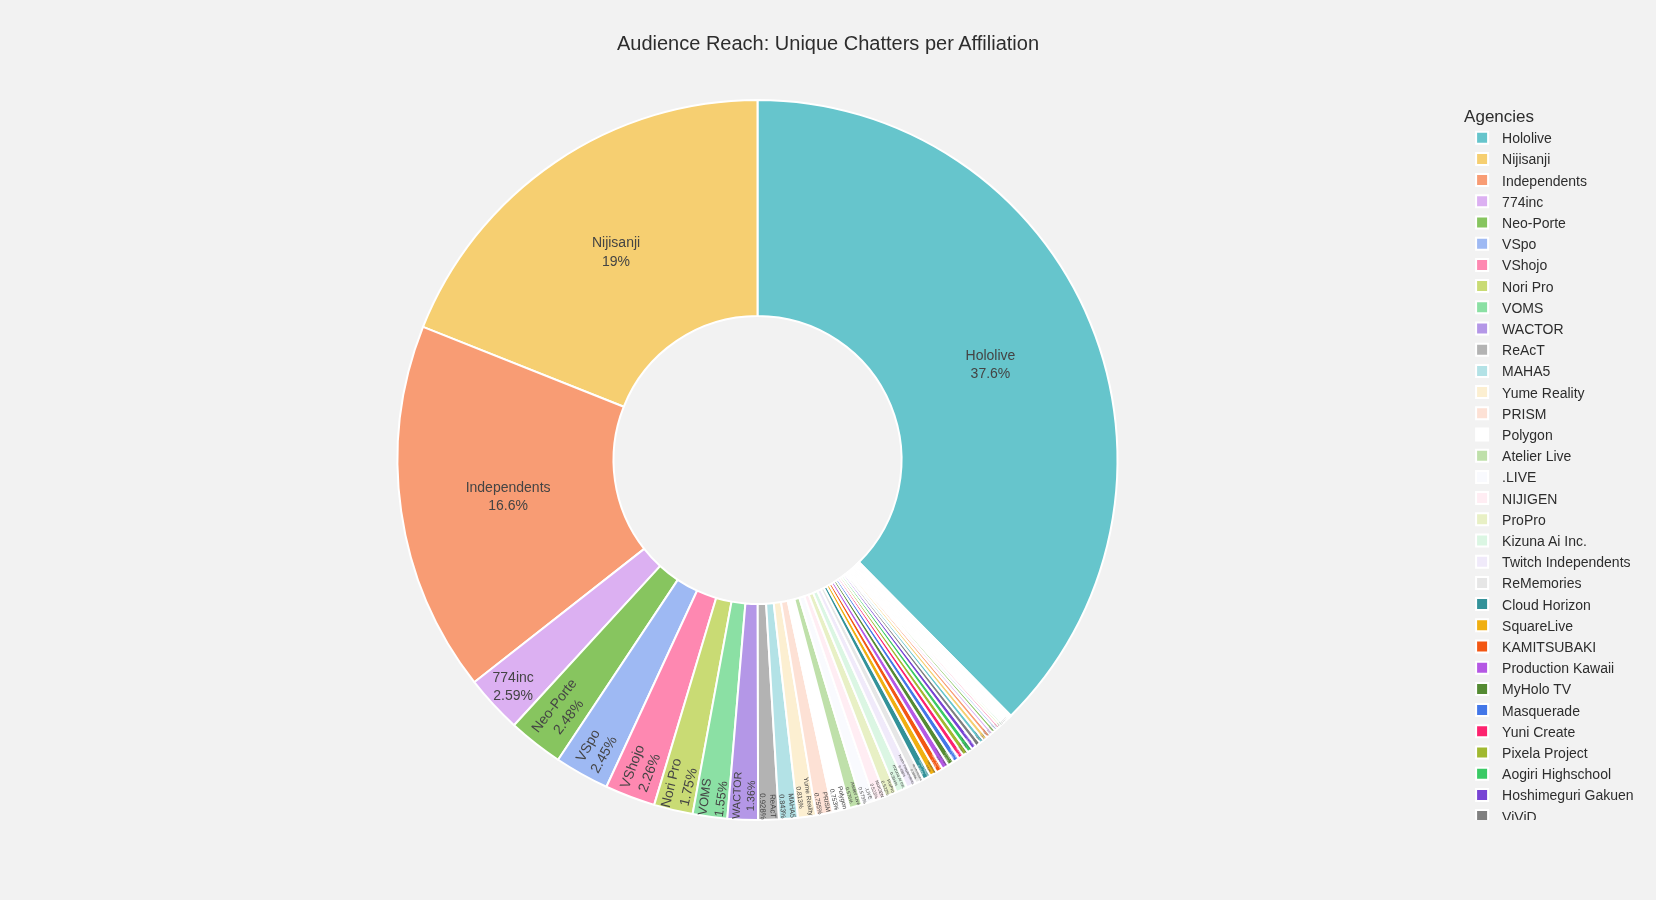

In [29]:
affiliation_unique_chatters_df = (
    get_affiliation_unique_chatter_counts().toPandas()
)

fig = px.pie(
    affiliation_unique_chatters_df,
    values="unique_chatters",
    names="affiliation",
    title="Audience Reach: Unique Chatters per Affiliation",
    hole=0.4,
    color_discrete_sequence=px.colors.qualitative.Pastel,
    template="plotly_white",
    width=1600,
    height=900,
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label",
    hoverinfo="label+value+percent",
    marker=dict(line=dict(color="#FFFFFF", width=2)),
)

fig.update_layout(
    plot_bgcolor="#F2F2F2",
    paper_bgcolor="#F2F2F2",
    font=dict(color="#2D2D2D", size=14),
    title_x=0.5,
    legend_title="Agencies",
)

fig.show()


In [30]:
get_affiliation_unique_chatter_counts().show(10)

+------------+---------------+
| affiliation|unique_chatters|
+------------+---------------+
|    Hololive|        2342738|
|   Nijisanji|        1182972|
|Independents|        1036025|
|      774inc|         161602|
|   Neo-Porte|         154483|
|        VSpo|         152660|
|      VShojo|         140971|
|    Nori Pro|         108887|
|        VOMS|          96529|
|      WACTOR|          84959|
+------------+---------------+
only showing top 10 rows


-----

### Window Functions: Ranking Top VTubers Within Each Affiliation

Business Objective: Create an internal leaderboard for every agency. Instead of comparing an indie to a massive Hololive star, this ranks talents strictly against their direct agency peers.
    
Concepts: `RANK() OVER(PARTITION BY ... ORDER BY ...)`

In [31]:
def get_agency_channel_rankings():
    """Return each channel chat-volume rank within its affiliation."""
    query = """
    WITH AgencyStats AS (
        SELECT
            ch.affiliation,
            ch.englishName,
            COUNT(1) AS chat_volume
        FROM chats c
        JOIN channels ch
            ON c.channelId = ch.channelId
        WHERE ch.affiliation IS NOT NULL
        GROUP BY ch.affiliation, ch.englishName
    )
    SELECT
        affiliation,
        englishName,
        chat_volume,
        RANK() OVER (
            PARTITION BY affiliation
            ORDER BY chat_volume DESC
        ) AS rank_in_agency
    FROM AgencyStats
    ORDER BY affiliation ASC, rank_in_agency ASC;
    """
    return spark.sql(query)


In [32]:
agency_channel_rankings_df = get_agency_channel_rankings().toPandas()
affiliations = agency_channel_rankings_df["affiliation"].dropna().unique()
df_top = agency_channel_rankings_df[
    agency_channel_rankings_df["rank_in_agency"] <= 20
]

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "Top VTubers by Chat Volume",
        "Volume Distribution Curve (Power Law)",
    ),
    horizontal_spacing=0.1,
)

for index, affiliation in enumerate(affiliations):
    affiliation_df = df_top[df_top["affiliation"] == affiliation]
    is_visible = index == 0

    fig.add_trace(
        go.Bar(
            x=affiliation_df["englishName"],
            y=affiliation_df["chat_volume"],
            name=f"{affiliation} (Bar)",
            marker_color="#636EFA",
            text=affiliation_df["chat_volume"],
            texttemplate="%{y:.2s}",
            textposition="outside",
            visible=is_visible,
            showlegend=False,
        ),
        row=1,
        col=1,
    )

    fig.add_trace(
        go.Scatter(
            x=affiliation_df["rank_in_agency"],
            y=affiliation_df["chat_volume"],
            mode="lines+markers",
            name=f"{affiliation} (Line)",
            line=dict(color="#00CC96", width=4),
            marker=dict(size=8, line=dict(width=1, color="white")),
            visible=is_visible,
            showlegend=False,
        ),
        row=1,
        col=2,
    )

buttons = []
traces_per_affiliation = 2

for index, affiliation in enumerate(affiliations):
    visibility = [False] * (len(affiliations) * traces_per_affiliation)
    visibility[index * 2] = True
    visibility[index * 2 + 1] = True
    buttons.append(
        dict(
            label=affiliation,
            method="update",
            args=[
                {"visible": visibility},
                {"title": f"Engagement Dashboard: {affiliation}"},
            ],
        )
    )

fig.update_layout(
    width=1600,
    height=900,
    template="plotly_white",
    plot_bgcolor="#F2F2F2",
    paper_bgcolor="#F2F2F2",
    font=dict(color="#2D2D2D"),
    title={
        "text": f"Engagement Dashboard: {affiliations[0]}",
        "y": 0.95,
        "x": 0.5,
        "xanchor": "center",
        "yanchor": "top",
    },
    updatemenus=[
        dict(
            active=0,
            buttons=buttons,
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=1.0,
            xanchor="right",
            y=1.12,
            yanchor="top",
            bgcolor="#FFFFFF",
            font=dict(color="#2D2D2D"),
        )
    ],
    margin=dict(t=120, b=100),
)

fig.update_xaxes(
    title_text="VTuber Name",
    row=1,
    col=1,
    tickangle=-45,
    showgrid=False,
)
fig.update_yaxes(title_text="Total Chat Volume", row=1, col=1, gridcolor="white")
fig.update_xaxes(title_text="Agency Rank", row=1, col=2, showgrid=False)
fig.update_yaxes(title_text="Total Chat Volume", row=1, col=2, gridcolor="white")

fig.show()


In [33]:
get_agency_channel_rankings().show()

+-----------+-------------------+-----------+--------------+
|affiliation|        englishName|chat_volume|rank_in_agency|
+-----------+-------------------+-----------+--------------+
|      .LIVE|    Kakyouin Chieri|    4627495|             1|
|      .LIVE|        Kagura Suzu|    2257923|             2|
|      .LIVE|         Carro Pino|    1393998|             3|
|      .LIVE|        Yamato Iori|    1355469|             4|
|      .LIVE|      Mokota Mememe|     815283|             5|
|      .LIVE| Dennou Shojo Shiro|     715679|             6|
|      .LIVE|     Rurun Rururica|     576600|             7|
|      .LIVE|     Yaezawa Natori|     447017|             8|
|      .LIVE|   Nanahoshi Milily|     399271|             9|
|      .LIVE|             Rikumu|     396700|            10|
|      .LIVE|    Kitakami Futaba|     235566|            11|
|      .LIVE|       Kongou Iroha|      88512|            12|
|      .LIVE|         Merry Milk|      51470|            13|
|      .LIVE|           

--------

### Window Functions: Cumulative Engagement Growth by Affiliation

Business Objective: Visualize the compounding growth of agencies over time by tracking their running total of chat messages day over day.

Concepts: `SUM() OVER(... ROWS BETWEEN UNBOUNDED PRECEDING...)`

In [34]:
def get_cumulative_affiliation_volume():
    """Return daily and cumulative chat volume by affiliation."""
    query = """
    WITH DailyAgencyVolume AS (
        SELECT
            ch.affiliation,
            TO_DATE(c.timestamp) AS chat_date,
            COUNT(1) AS daily_volume
        FROM chats c
        JOIN channels ch
            ON c.channelId = ch.channelId
        WHERE ch.affiliation IS NOT NULL
        GROUP BY ch.affiliation, TO_DATE(c.timestamp)
    )
    SELECT
        affiliation,
        chat_date,
        daily_volume,
        SUM(daily_volume) OVER (
            PARTITION BY affiliation
            ORDER BY chat_date
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS cumulative_volume
    FROM DailyAgencyVolume
    ORDER BY affiliation, chat_date;
    """
    return spark.sql(query)


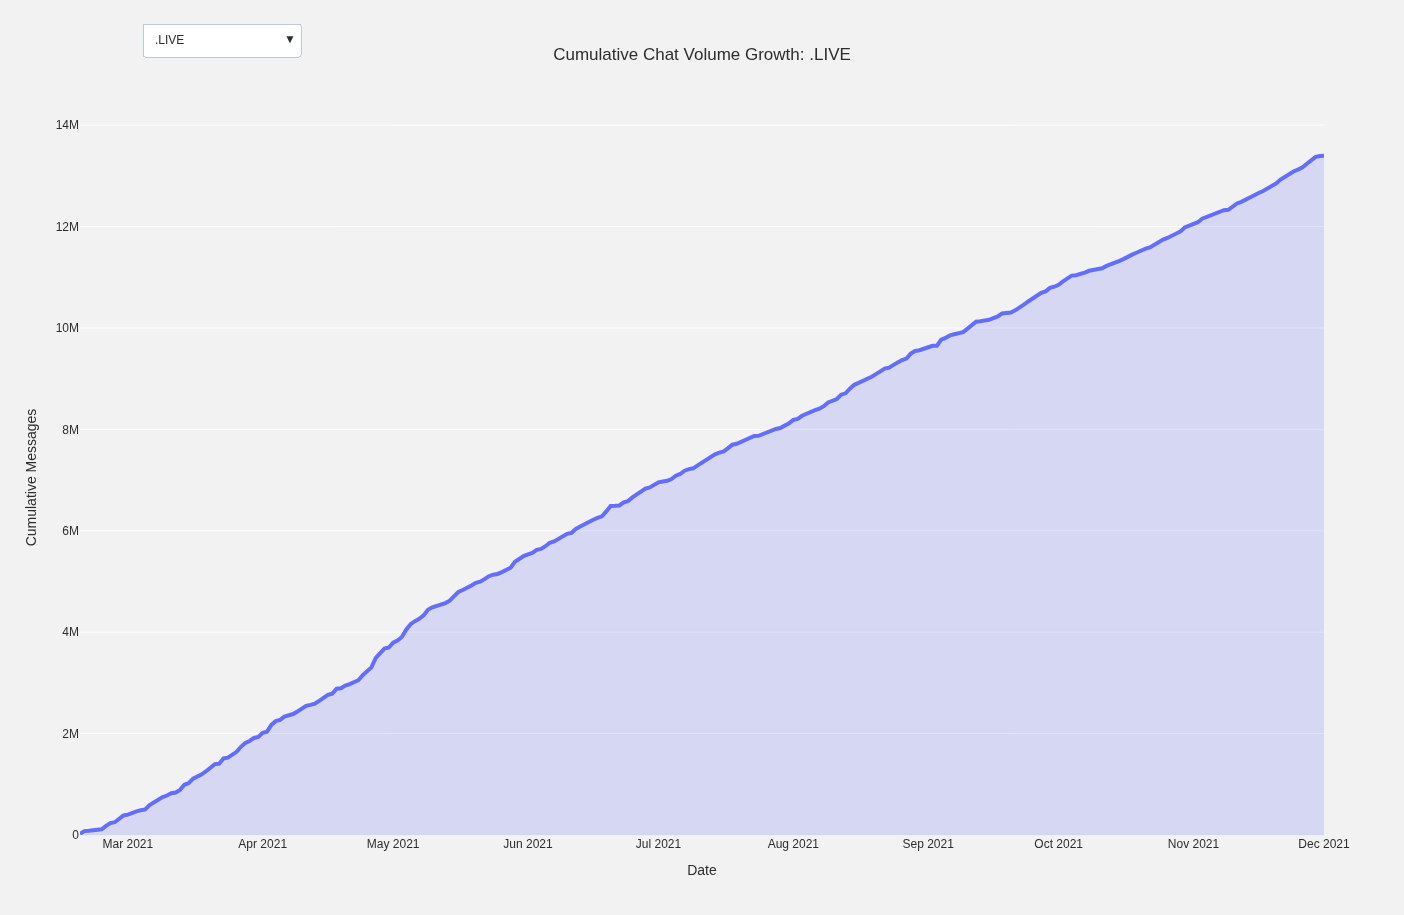

In [35]:
cumulative_affiliation_volume_df = get_cumulative_affiliation_volume().toPandas()
affiliations = cumulative_affiliation_volume_df["affiliation"].dropna().unique()

fig = go.Figure()

for index, affiliation in enumerate(affiliations):
    affiliation_df = cumulative_affiliation_volume_df[
        cumulative_affiliation_volume_df["affiliation"] == affiliation
    ]

    fig.add_trace(
        go.Scatter(
            x=affiliation_df["chat_date"],
            y=affiliation_df["cumulative_volume"],
            mode="lines",
            name=affiliation,
            line=dict(width=4, color="#636EFA"),
            fill="tozeroy",
            fillcolor="rgba(99, 110, 250, 0.2)",
            visible=index == 0,
        )
    )

buttons = []
for index, affiliation in enumerate(affiliations):
    visibility = [False] * len(affiliations)
    visibility[index] = True
    buttons.append(
        dict(
            label=affiliation,
            method="update",
            args=[
                {"visible": visibility},
                {"title": f"Cumulative Chat Volume Growth: {affiliation}"},
            ],
        )
    )

fig.update_layout(
    width=1600,
    height=900,
    template="plotly_white",
    plot_bgcolor="#F2F2F2",
    paper_bgcolor="#F2F2F2",
    font=dict(color="#2D2D2D"),
    title={
        "text": f"Cumulative Chat Volume Growth: {affiliations[0]}",
        "x": 0.5,
        "xanchor": "center",
    },
    xaxis_title="Date",
    yaxis_title="Cumulative Messages",
    updatemenus=[
        dict(
            active=0,
            buttons=buttons,
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=0.05,
            xanchor="left",
            y=1.15,
            yanchor="top",
            bgcolor="#FFFFFF",
            font=dict(color="#2D2D2D"),
        )
    ],
    margin=dict(t=120, b=80),
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(gridcolor="white")
fig.show()


In [36]:
get_cumulative_affiliation_volume().show()

+-----------+----------+------------+-----------------+
|affiliation| chat_date|daily_volume|cumulative_volume|
+-----------+----------+------------+-----------------+
|      .LIVE|2021-02-18|       25477|            25477|
|      .LIVE|2021-02-19|       50790|            76267|
|      .LIVE|2021-02-20|        6980|            83247|
|      .LIVE|2021-02-21|        2897|            86144|
|      .LIVE|2021-02-22|       14046|           100190|
|      .LIVE|2021-02-23|       11693|           111883|
|      .LIVE|2021-02-24|       67185|           179068|
|      .LIVE|2021-02-25|       54890|           233958|
|      .LIVE|2021-02-26|       18275|           252233|
|      .LIVE|2021-02-27|       69066|           321299|
|      .LIVE|2021-02-28|       65023|           386322|
|      .LIVE|2021-03-01|       15150|           401472|
|      .LIVE|2021-03-02|       40705|           442177|
|      .LIVE|2021-03-03|       23383|           465560|
|      .LIVE|2021-03-04|       24106|           

-----
### Time-Series: 7-Day Moving Average of Unique Active Chatters per Agency

Business Objective: Smooth out the volatility of single-day massive events to understand the true underlying **daily active user** (DAU) base supporting each affiliation over time.

Concepts: Time-series smoothing, Window Functions with `ROWS BETWEEN`

In [37]:
def get_affiliation_daily_active_chatters():
    """Return daily active chatters and 7-day averages by affiliation."""
    query = """
    WITH DailyActiveChatters AS (
        SELECT
            ch.affiliation,
            TO_DATE(c.timestamp) AS chat_date,
            COUNT(DISTINCT c.authorChannelId) AS daily_active_users
        FROM chats c
        JOIN channels ch
            ON c.channelId = ch.channelId
        WHERE ch.affiliation IS NOT NULL
        GROUP BY ch.affiliation, TO_DATE(c.timestamp)
    )
    SELECT
        affiliation,
        chat_date,
        daily_active_users,
        ROUND(AVG(daily_active_users) OVER (
            PARTITION BY affiliation
            ORDER BY chat_date
            ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
        ), 2) AS 7_day_mau
    FROM DailyActiveChatters
    ORDER BY affiliation, chat_date;
    """
    return spark.sql(query)


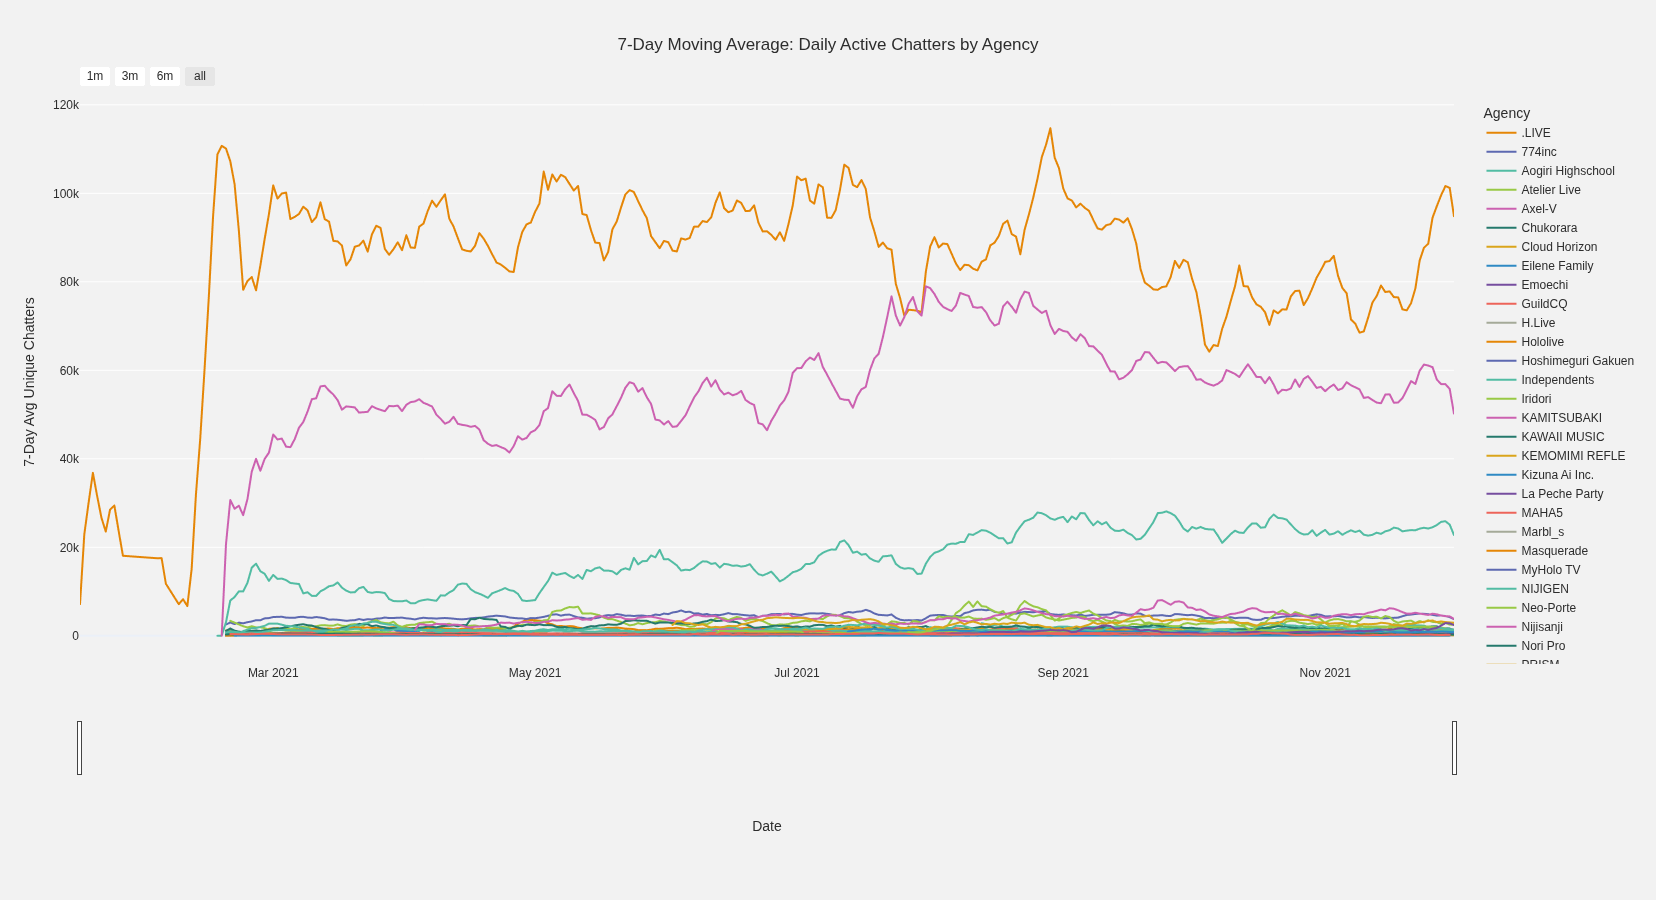

In [38]:
daily_active_chatters_df = get_affiliation_daily_active_chatters().toPandas()

fig = px.line(
    daily_active_chatters_df,
    x="chat_date",
    y="7_day_mau",
    color="affiliation",
    title="7-Day Moving Average: Daily Active Chatters by Agency",
    labels={
        "chat_date": "Date",
        "7_day_mau": "7-Day Avg Unique Chatters",
        "affiliation": "Agency",
    },
    template="plotly_white",
    color_discrete_sequence=px.colors.qualitative.Vivid,
    width=1600,
    height=900,
)

fig.update_layout(
    plot_bgcolor="#F2F2F2",
    paper_bgcolor="#F2F2F2",
    font=dict(color="#2D2D2D"),
    title_x=0.5,
    hovermode="x unified",
    margin=dict(t=100, b=100),
    yaxis=dict(
        autorange=True,
        fixedrange=False,
        gridcolor="white",
    ),
)

fig.update_xaxes(
    showgrid=False,
    rangeslider_visible=True,
    rangeselector=dict(
        bgcolor="#FFFFFF",
        activecolor="#E6E6E6",
        buttons=list(
            [
                dict(count=1, label="1m", step="month", stepmode="backward"),
                dict(count=3, label="3m", step="month", stepmode="backward"),
                dict(count=6, label="6m", step="month", stepmode="backward"),
                dict(step="all"),
            ]
        ),
    ),
)

fig.show()


In [39]:
get_affiliation_daily_active_chatters().show()

+-----------+----------+------------------+---------+
|affiliation| chat_date|daily_active_users|7_day_mau|
+-----------+----------+------------------+---------+
|      .LIVE|2021-02-18|              1215|   1215.0|
|      .LIVE|2021-02-19|              1695|   1455.0|
|      .LIVE|2021-02-20|               457|  1122.33|
|      .LIVE|2021-02-21|               210|   894.25|
|      .LIVE|2021-02-22|               509|    817.2|
|      .LIVE|2021-02-23|               916|   833.67|
|      .LIVE|2021-02-24|              2520|  1074.57|
|      .LIVE|2021-02-25|              1623|  1132.86|
|      .LIVE|2021-02-26|              1106|  1048.71|
|      .LIVE|2021-02-27|              2058|  1277.43|
|      .LIVE|2021-02-28|              2250|  1568.86|
|      .LIVE|2021-03-01|              1314|  1683.86|
|      .LIVE|2021-03-02|              1510|  1768.71|
|      .LIVE|2021-03-03|              1114|  1567.86|
|      .LIVE|2021-03-04|              1157|  1501.29|
|      .LIVE|2021-03-05|    

# VI. Overall Results Summary

The results show that VTuber live-chat engagement is not evenly distributed across all channels. A few major agencies and top creators generated a large portion of the total chat activity.

Hololive had the highest total message volume and the largest unique chatting audience. Nijisanji also showed very strong engagement and ranked second in most agency-level results. Independent VTubers also contributed a large amount of chat activity, which shows that strong communities are not only limited to big agencies.

At the channel level, Usada Pekora, Sakura Miko, Gawr Gura, Takanashi Kiara, and Oozora Subaru showed very high chat volume. These creators appears to have very active live audiences.

The monthly trend suggests that chat activity was strongest around the middle of 2021, especially in August. However, January and December should be interpreted carefully because the data for these months may be incomplete.

Overall, the study shows that live-chat activity can provide a better understanding of audience engagement than subscriber count alone.

# VII. Conclusion

This study shows that large-scale VTuber live-chat records can be used to measure audience engagement across channels, agencies, streams, and time periods. By using Apache Spark, the project was able to process and analyze a large dataset that would be difficult to handle using traditional tools.

The analysis found that Hololive and Nijisanji had the strongest overall engagement in 2021. Hololive led in both total chat messages and unique chatters, which shows that it had both high activity and broad audience participation.

At the individual level, VTubers such as Usada Pekora, Sakura Miko, Gawr Gura, and Takanashi Kiara generated very high chat volume. These results suggest that their livestreams attracted highly active live-chat communities.

The study answers the main problem by showing that live-chat behavior is a useful way to compare VTuber audience engagement. Chat volume, unique chatters, message length, loyalty score, and chat velocity each gives a different view of how audiences interact during livestreams.

# VIII. Limitations and Future Work

This study has several limitations. First, chat volume does not always mean positive engagement. Some messages may be spam, repeated emojis, or simple reactions. Because of this, high chat count should not automatically be treated as high-quality engagement.

Second, bodyLength is only an indirect measure of message depth. A longer message may be meaningful, but it may also be unrelated or repetitive. The study did not analyze the actual content or sentiment of the messages.

Third, the isMember column was not used, so the study does not compare paid members and non-members. This limits the ability to understand whether members behave differently from general viewers.

Fourth, January and December had unusually low chat counts. This may be caused by incomplete, corrupted, or excluded data files. Because of this, the monthly trend should be interpreted with caution.

For future work, the study can be improved by adding sentiment analysis, language detection, spam filtering, topic modeling, and member versus non-member comparison. It would also be useful to combine chat data with stream metadata, subscriber count, collaboration events, and video categories.

# IX. Recommendations

Based on the findings, sponsors and agencies should not only depend on subscriber count when evaluating VTuber influence. Live-chat activity gives a more direct view of how active the audience are during streams.

For broad campaign reach, Hololive and Nijisanji are strong choices because they had the highest total chat volume and unique chatter count. For individual creator selection, VTubers such as **Usada Pekora**, **Sakura Miko**, **Gawr Gura**, and **Takanashi Kiara** may be strong candidates because they showed high live-chat activity.

However, sponsors should also consider different engagement metrics together. `Total chats` can show activity volume, `unique chatters` can show audience reach, message length can suggest conversational depth, loyalty score can show fan concentration, and peak chat velocity can show moments of high audience attention.

Using these metrics together gives a more balanced understanding of VTuber audience engagement.

## References

Uechi, Y. (2022, February). *VTuber 1B: Large-scale live chat and moderation events dataset* (Version 37). HoloData. https://holodata.org/vtuber-1b

Uechi, Y. (n.d.). *VTuber livechat*. Kaggle. Retrieved May 12, 2026, from https://www.kaggle.com/datasets/uetchy/vtuber-livechat

Uechi, Y. (n.d.). *VTuber livechat elements*. Kaggle. Retrieved May 12, 2026, from https://www.kaggle.com/datasets/uetchy/vtuber-livechat-elements